# Supermarket Saled Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_excel("C:/Users/HP/Documents/Data Analysis Training/Excel/Supermarket Sales Data Analyiss 2.xlsx")

## KPI Summary

In [4]:
total_revenue = df["Sales"].sum()
avg_sale = df["Sales"].mean()
total_transactions = len(df)
total_profit = df["gross income"].sum()
avg_rating = df["Rating"].mean()

In [5]:
kpi = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Average Sale",
        "Total Transactions",
        "Total Profit",
        "Average Rating"
    ],
    "Value":[
        round(total_revenue,2),
        round(avg_sale,2),
        round(total_transactions,2),
        round(total_profit,2),
        round(avg_rating,2)
    ]
})
kpi

,Metric,Value
0,Total Revenue,322966.75
1,Average Sale,322.97
2,Total Transactions,1000.00
3,Total Profit,15379.37
4,Average Rating,6.97


## Data Understanding

In [6]:
df.shape

(1000, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [8]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [9]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905e+00,15.379369,6.97270
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905e+00,49.650000,10.00000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,6.131498e-14,11.708825,1.71858


## Data Cleaning

In [10]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## Key Business Metrics

In [12]:
total_sales=df["Sales"].sum()
print(round(total_sales, 2))

322966.75


In [13]:
gross_income=df["gross income"].sum()
print(round(gross_income, 2))

15379.37


In [14]:
average_sales=df["Sales"].mean()
print(round(average_sales, 2))

322.97


In [15]:
len(df)

1000

## Product Line Analysis

In [16]:
product_sales=df.groupby("Product line")["Sales"].sum()
print(product_sales)

Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Sales, dtype: float64


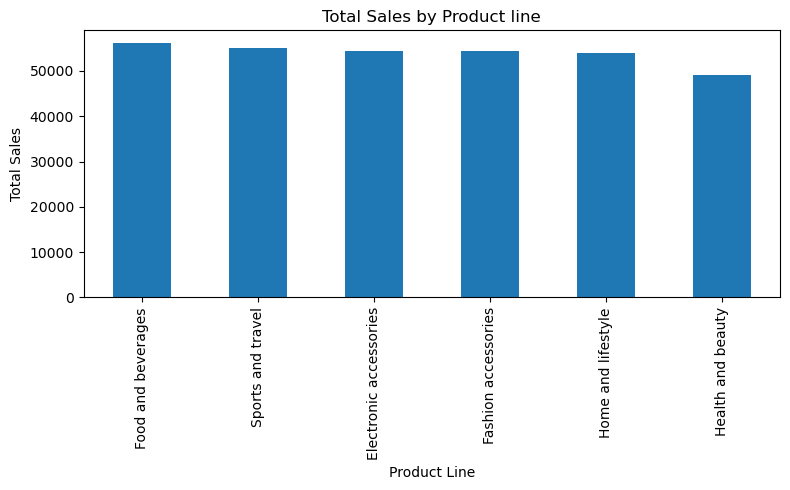

In [17]:
plt.figure(figsize=(8,5))
product_sales.sort_values(ascending=False).plot(kind="bar")
plt.title("Total Sales by Product line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

Food and beverages generated the highest revenue while Health and beauty generated the lowest.

## Branch Performance

In [18]:
branch_sales=df.groupby("Branch")["Sales"].sum()
print(branch_sales)

Branch
Alex     106200.3705
Cairo    106197.6720
Giza     110568.7065
Name: Sales, dtype: float64


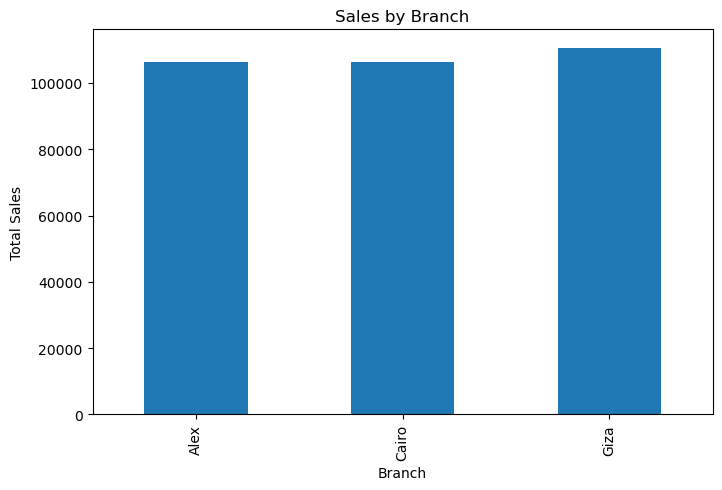

In [19]:
plt.figure(figsize=(8,5))
branch_sales.plot(kind="bar")
plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.show()

## City Performance

In [20]:
city_sales=df.groupby("City")["Sales"].sum()
print(city_sales)

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Sales, dtype: float64


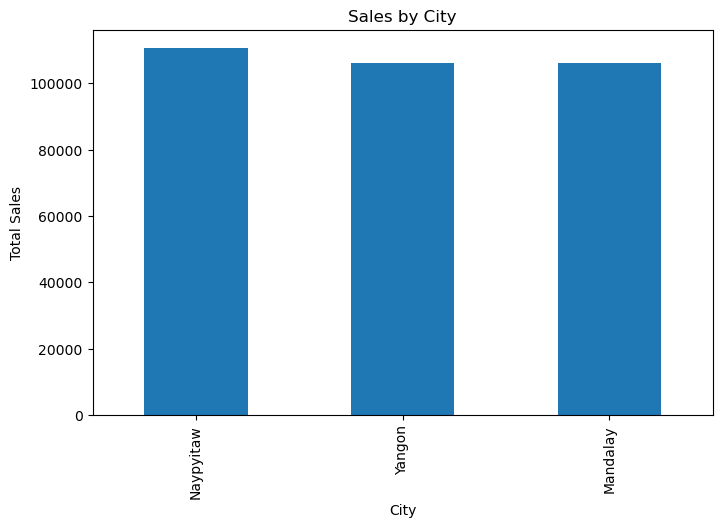

In [21]:
plt.figure(figsize=(8,5))
city_sales.sort_values(ascending=False).plot(kind="bar")
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

Most of the revenue of the company is obtained form Naypyitaw city followed by Mandalay and Yangon.

## Customer Analysis

In [22]:
gender_sales=df.groupby("Gender")["Sales"].sum()
print(gender_sales)

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


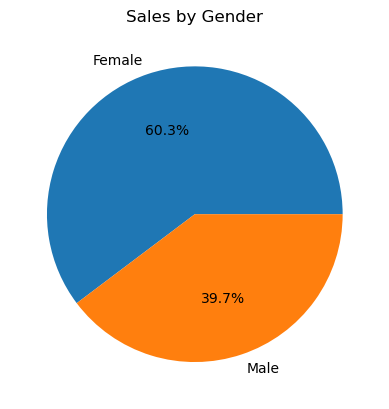

In [23]:
gender_sales.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Sales by Gender")
plt.show()

Female customers contributes to the highest revenue of the company.

## Payment Method Analysis 

In [24]:
payment_sales=df.groupby("Payment")["Sales"].sum()
print(payment_sales)

Payment
Cash           112206.570
Credit card    100767.072
Ewallet        109993.107
Name: Sales, dtype: float64


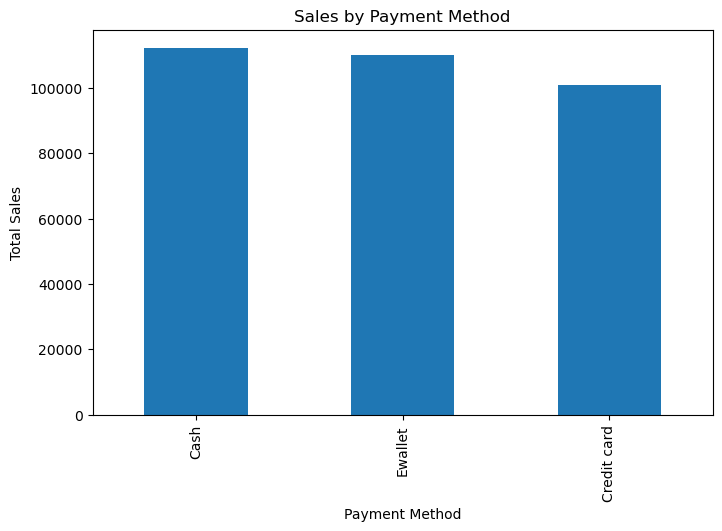

In [25]:
plt.figure(figsize=(8,5))
payment_sales.sort_values(ascending=False).plot(kind="bar")
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.show()

Most of the customers prefer to pay in cash.

## Product Rating

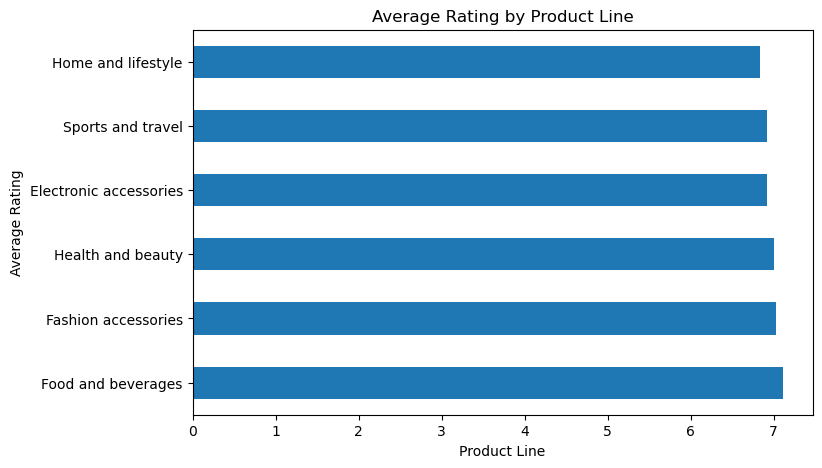

In [26]:
plt.figure(figsize=(8,5))
rating=df.groupby("Product line")["Rating"].mean()
rating.sort_values(ascending=False).plot(kind="barh")
plt.title("Average Rating by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Rating")
plt.show()

Food and beverages product line gets the highest average rating indicating most of the customers are satisfied by this product line.

## Monthly Sales

In [27]:
df["Date"]=pd.to_datetime(df["Date"])
df["Month_Number"]=df["Date"].dt.month
df["Month"]=df["Date"].dt.month_name()

In [28]:
monthly_sales=(df.groupby(["Month_Number","Month"])["Sales"].sum())
print(monthly_sales)

Month_Number  Month   
1             January     116291.868
2             February     97219.374
3             March       109455.507
Name: Sales, dtype: float64


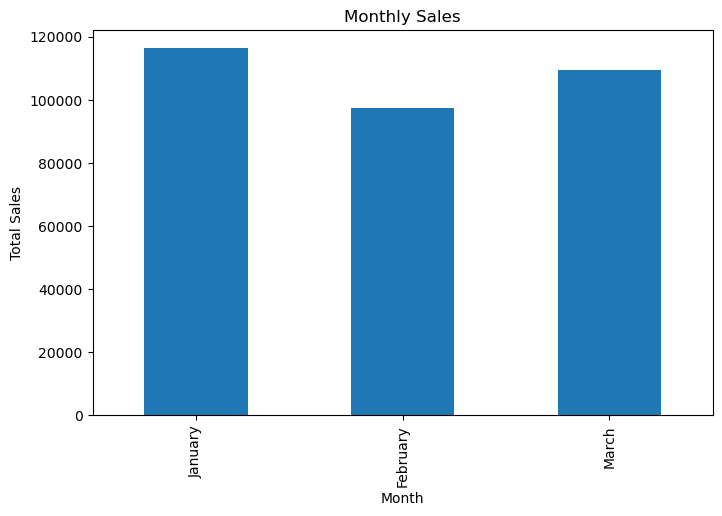

In [29]:
plt.figure(figsize=(8,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales")
plt.xticks(ticks=[0,1,2], labels=["January", "February", "March"])
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

The smallest sales is made on February and the highest is on January.

## Correlation Analysis

In [30]:
df[["Sales","Quantity","Rating","gross income"]].corr()

,Sales,Quantity,Rating,gross income
Sales,1.000000,0.705510,-0.036442,1.000000
Quantity,0.705510,1.000000,-0.015815,0.705510
Rating,-0.036442,-0.015815,1.000000,-0.036442
gross income,1.000000,0.705510,-0.036442,1.000000


Gross income is obtained from sales that leads to the strong relationship between them.

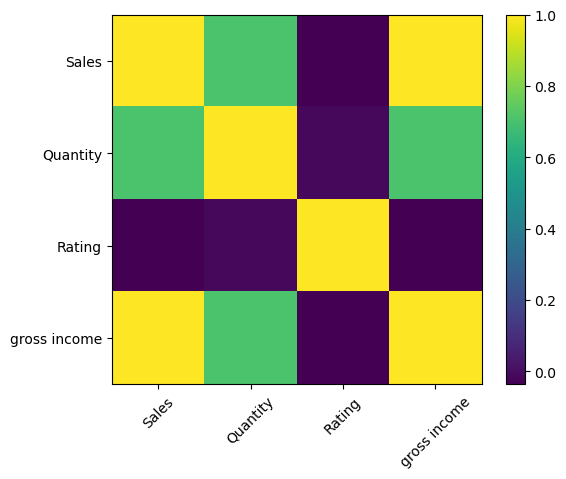

In [31]:
corr = df[["Sales","Quantity","Rating","gross income"]].corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

Sales and gross income have a strong correlation.

In [32]:
pd.crosstab(
    df["Customer type"],
    df["Product line"])

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Customer type,,,,,,
Member,90,96,104,86,92,97
Normal,80,82,70,66,68,69


## Time Series Analysis

In [33]:
daily_sales = df.groupby("Date")["Sales"].sum()

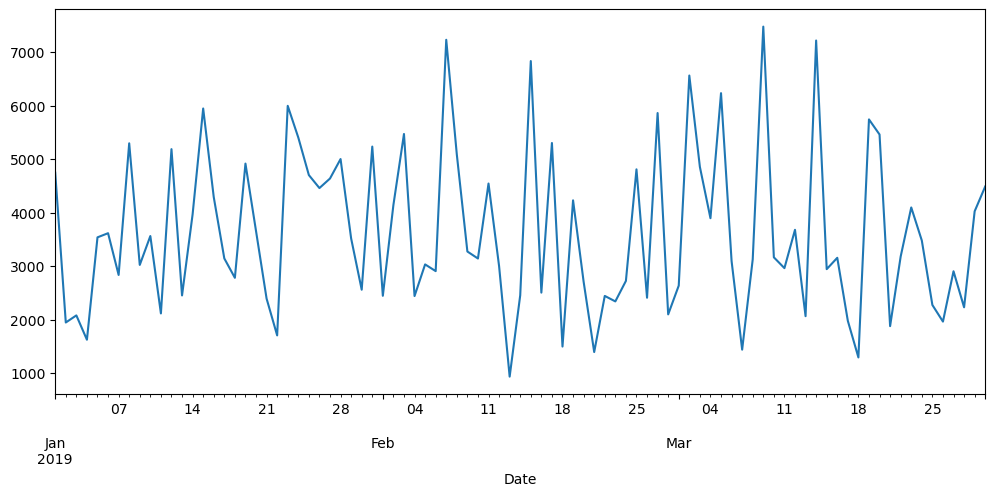

In [34]:
plt.figure(figsize=(12,5))
daily_sales.plot(kind="line")
plt.show()

The daily sales trend showed fluctuations in revenue over time, highlighting periods of stronger and weaker sales performance throughout the quarter.

In [35]:
df["Weekday"] = df["Date"].dt.day_name()
df["Weekday_Number"]=df["Date"].dt.dayofweek

   Weekday_Number    Weekday       Sales
0               0     Monday  37899.0780
1               1    Tuesday  51482.2455
2               2  Wednesday  43731.1350
3               3   Thursday  45349.2480
4               4     Friday  43926.3405
5               5   Saturday  56120.8095
6               6     Sunday  44457.8925


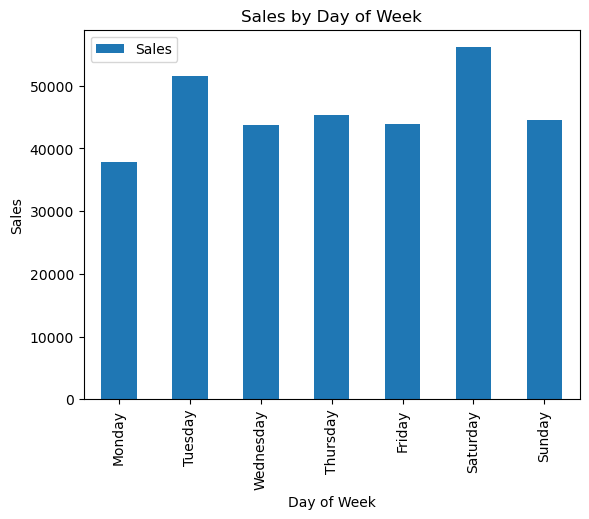

In [36]:
weekly_sales = (
    df.groupby(["Weekday_Number", "Weekday"])["Sales"]
      .sum()
      .reset_index()
      .sort_values("Weekday_Number")
)
print(weekly_sales)
weekly_sales.plot(
    x="Weekday",
    y="Sales",
    kind="bar"
)

plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Sales")
plt.show()

The highest sales are done on saturdays followed by Tuesdays and the lowest sale is on Mondays.

## Key Findings

- Highest revenue is obtained from Food and Beverages
- Giza branch outperformed the other branches
- Naypyitaw city shows best sales performance
- Female customers contributed higher revenue
- Most customers pays in Cash followed by E-wallet and Credit card
- Food and Beverages products received the highest ratings
- The highest sales is made in January and the lowest in February
- There is a strong correlation between sales and gross income